In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import math
from sklearn.preprocessing import StandardScaler

In [2]:
data=pd.read_csv(r"C:\Users\Arvind\Downloads\Online Retail (1).csv")

In [3]:
data.shape

(541909, 8)

In [4]:
data.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [6]:
# null values
data.isnull().mean()*100

InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
CustomerID     24.926694
Country         0.000000
dtype: float64

In [7]:
data.duplicated().sum()


5268

In [8]:
data.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [9]:
data.describe(include="object")

,InvoiceNo,StockCode,Description,InvoiceDate,Country
count,541909,541909,540455,541909,541909
unique,25900,4070,4223,23260,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10/31/11 14:41,United Kingdom
freq,1114,2313,2369,1114,495478


In [10]:
df=data.copy()

In [11]:
# now we delete the duplicates 
df=df.drop_duplicates()

In [12]:
df.shape

(536641, 8)

In [13]:
df.duplicated().sum()

0

In [14]:
df.columns=df.columns.str.lower()

In [15]:
# drop null values
df=df.dropna()

In [16]:
df.isna().mean()

invoiceno      0.0
stockcode      0.0
description    0.0
quantity       0.0
invoicedate    0.0
unitprice      0.0
customerid     0.0
country        0.0
dtype: float64

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 401604 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   invoiceno    401604 non-null  object 
 1   stockcode    401604 non-null  object 
 2   description  401604 non-null  object 
 3   quantity     401604 non-null  int64  
 4   invoicedate  401604 non-null  object 
 5   unitprice    401604 non-null  float64
 6   customerid   401604 non-null  float64
 7   country      401604 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.6+ MB


In [18]:
# lets see the cancelled products
df["invoiceno"].astype('str')
df[df["invoiceno"].str.startswith('C')]

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country
141,C536379,D,Discount,-1,12/1/10 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/10 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/10 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/10 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/11 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/11 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/11 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/11 11:58,1.25,17315.0,United Kingdom


In [19]:
# delete this cancelled product for further analysis
df=df[~df["invoiceno"].str.startswith('C')]

In [20]:
df.shape

(392732, 8)

In [21]:
# products with unit price 0. this cannot be happend because a seller cannot sell their thing in free
df[df['unitprice']==0].shape

(40, 8)

In [22]:
# we just drop these rows
df=df[df['unitprice']>0]

In [23]:
df.shape

(392692, 8)

In [24]:
# change data type of invoicedate
df['invoicedate']=pd.to_datetime(df['invoicedate'],format='mixed')

In [25]:
# feature engineering
df['day']=df['invoicedate'].dt.day_name()
df['month']=df['invoicedate'].dt.month_name()
df['year']=df['invoicedate'].dt.year
df['hour']=df['invoicedate'].dt.hour
df['minute']=df['invoicedate'].dt.minute
df['second']=df['invoicedate'].dt.second

In [26]:
# make a total price
df['totalprice']=df['quantity']*df['unitprice']

In [27]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,day,month,year,hour,minute,second,totalprice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,20.34


In [28]:
# Which products are the most and least sold ones?
df['description'].value_counts().reset_index()

,description,count
0,WHITE HANGING HEART T-LIGHT HOLDER,2016
1,REGENCY CAKESTAND 3 TIER,1713
2,JUMBO BAG RED RETROSPOT,1615
3,ASSORTED COLOUR BIRD ORNAMENT,1395
4,PARTY BUNTING,1389
...,...,...
3872,GREEN WITH METAL BAG CHARM,1
3873,WHITE WITH METAL BAG CHARM,1
3874,BLUE/NAT SHELL NECKLACE W PENDANT,1
3875,PINK EASTER HENS+FLOWER,1


In [29]:
desc_df=df['description'].value_counts().reset_index()
desc_df.rename(columns={'index':'description name'},inplace=True)
# desc_df.rename(columns={'description':'counts'},inplace=True)
desc_df.head()

,description,count
0,WHITE HANGING HEART T-LIGHT HOLDER,2016
1,REGENCY CAKESTAND 3 TIER,1713
2,JUMBO BAG RED RETROSPOT,1615
3,ASSORTED COLOUR BIRD ORNAMENT,1395
4,PARTY BUNTING,1389


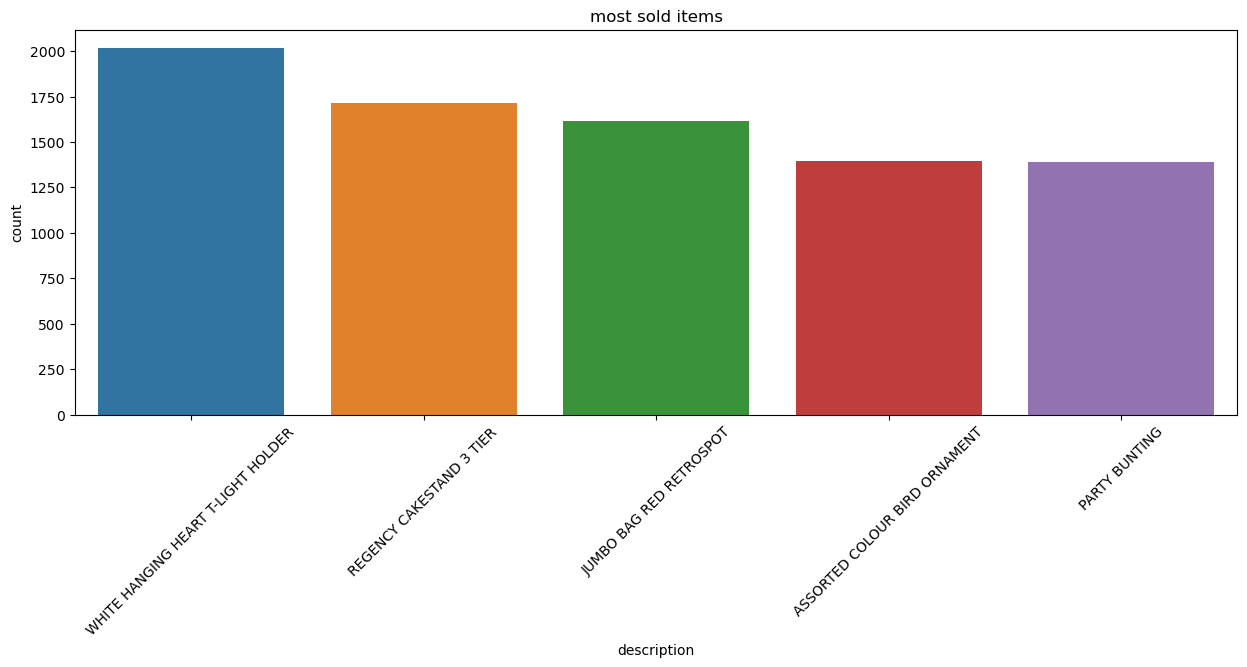

In [30]:
# plot bar chart for most sold things
plt.figure(figsize=[15,5])
sns.barplot(x='description',y='count',data=desc_df[:5])
plt.title('most sold items')
plt.xticks(rotation=45)
plt.show()

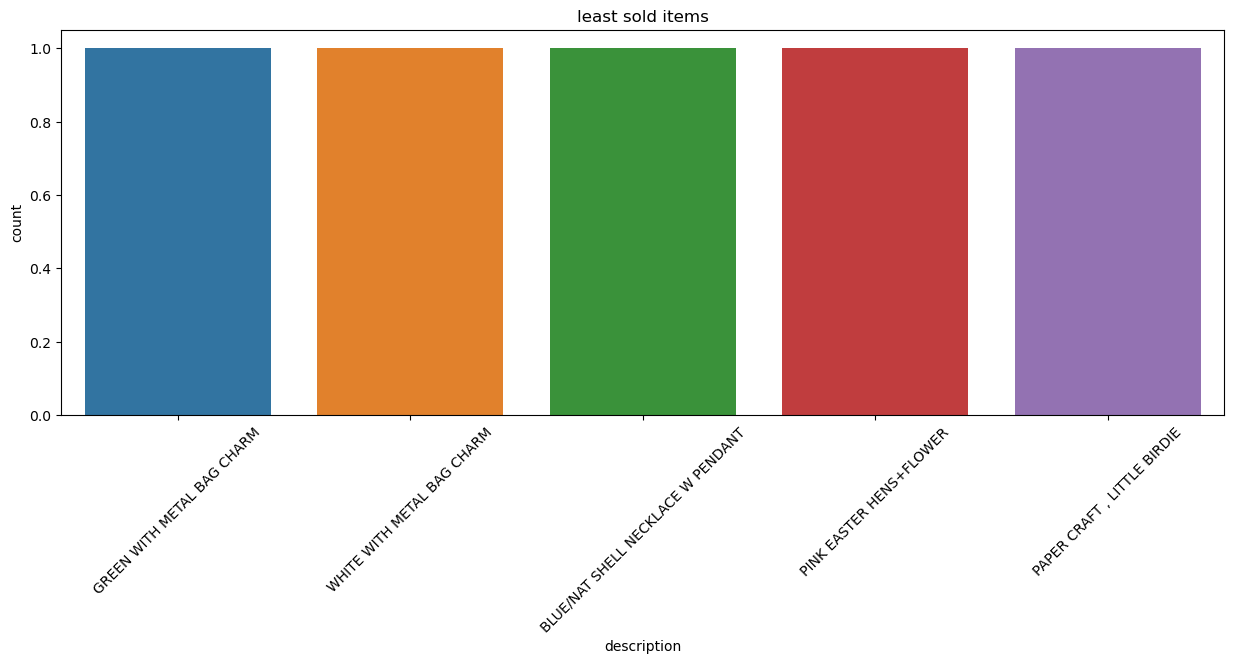

In [31]:
# least sold items
plt.figure(figsize=[15,5])
sns.barplot(x='description',y='count',data=desc_df[-5:])
plt.title('least sold items')
plt.xticks(rotation=45)
plt.show()

In [32]:
# Which countries has the most and least number of customers?
# df['country'].value_counts().reset_index()

In [33]:
country_df=df['country'].value_counts().reset_index()
country_df.rename(columns={'index':'country'},inplace=True)
country_df.head()

,country,count
0,United Kingdom,349203
1,Germany,9025
2,France,8326
3,EIRE,7226
4,Spain,2479


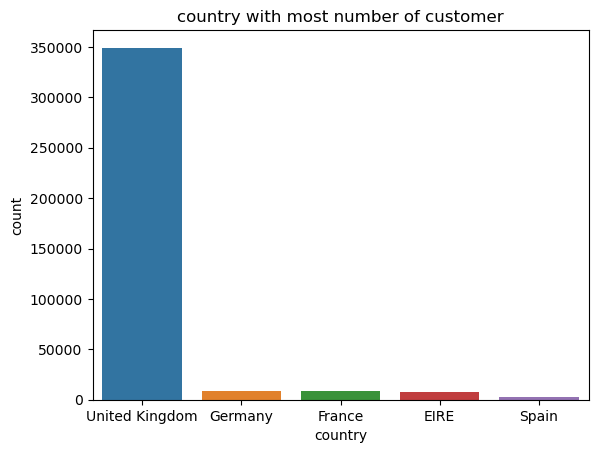

In [34]:
sns.barplot(x='country',y='count',data=country_df[:5])
plt.title('country with most number of customer')
plt.show()

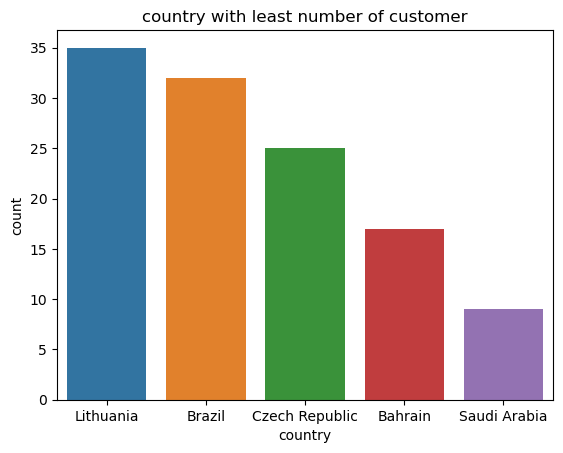

In [35]:
# country with least number of customer
sns.barplot(x='country',y='count',data=country_df[-5:])
plt.title('country with least number of customer')
plt.show()

In [36]:
# Which day of the week had the most and the least number of purchases?
day_df=df['day'].value_counts().reset_index()
day_df.head()

,day,count
0,Thursday,79243
1,Wednesday,68040
2,Tuesday,65744
3,Monday,64231
4,Sunday,61212


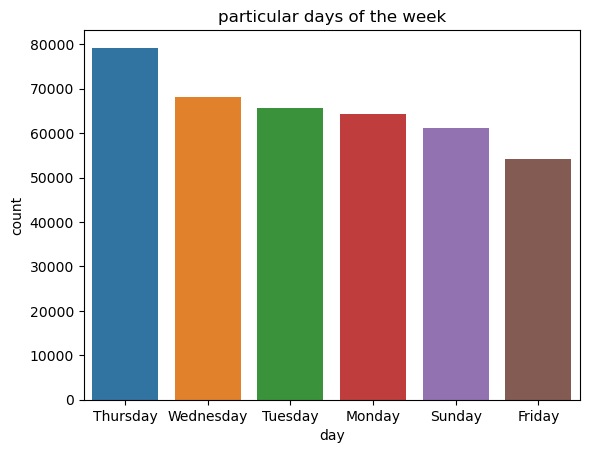

In [37]:
sns.barplot(x="day",y="count",data=day_df)
plt.title('particular days of the week')
plt.show()

1.Thursday has the most purchases in the week

2.Friday has the least purchases in the week


In [39]:
# Which month had the most and the least number of purchases?
month_df=df['month'].value_counts().reset_index()
month_df.head()

,month,count
0,November,63168
1,October,48793
2,December,42696
3,September,39669
4,May,28073


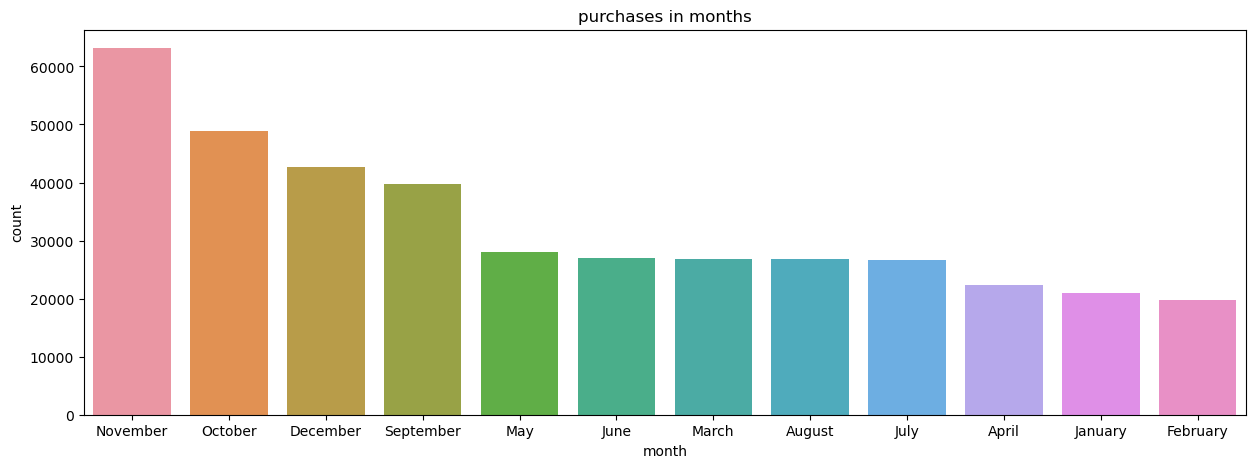

In [40]:
plt.figure(figsize=[15,5])
sns.barplot(x='month',y='count',data=month_df)
plt.title("purchases in months")
plt.show()

1.November has the most purchases in the year.

2.February has the least purchases in the year.

In [42]:
# Which hour of the day had the most and the least number of purchases?
hour_df=df['hour'].value_counts().reset_index()
hour_df.head()

,hour,count
0,12,70938
1,13,63019
2,14,53251
3,11,48365
4,15,44790


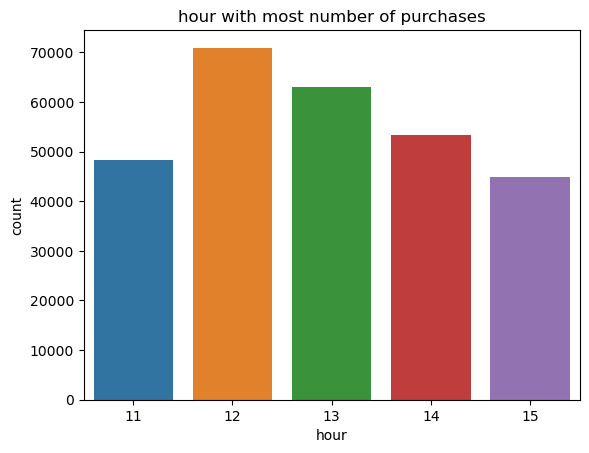

In [43]:
sns.barplot(x='hour',y='count',data=hour_df[:5])
plt.title('hour with most number of purchases')
plt.show()

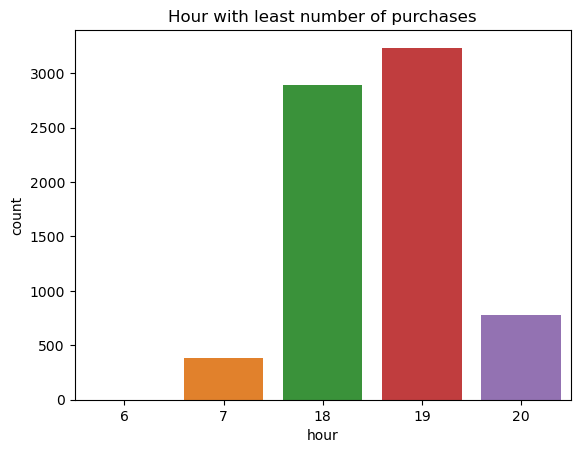

In [44]:
sns.barplot(x='hour',y='count',data=hour_df[-5:])
plt.title('Hour with least number of purchases')
plt.show()

In [45]:
# divide this time into 3 buckets morning,evening,afternoon 
def time_bucket(time):
    if time>=6 and time<=11:
        return"morning"
    elif time>=12 and time<=17:
        return"afternoon"
    else:
        return"evening"

df['time_day']=df['hour'].apply(time_bucket)

In [46]:
df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,day,month,year,hour,minute,second,totalprice,time_day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,15.30,morning
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,20.34,morning
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,22.00,morning
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,20.34,morning
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,20.34,morning


In [47]:
# df.to_excel("customer_segment.xlsx", index=False)

Text(0.5, 1.0, 'purchases according to time day')

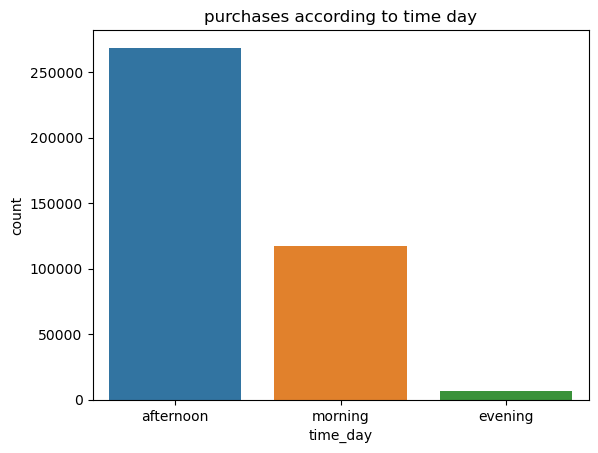

In [48]:
time_df=df['time_day'].value_counts().reset_index()
sns.barplot(x='time_day',y='count',data=time_df)
plt.title("purchases according to time day")

## RFM(Recency,Frequency,Monetry)

In [50]:
new_df=df[df['country']=='United Kingdom']

In [51]:
new_df.head()

,invoiceno,stockcode,description,quantity,invoicedate,unitprice,customerid,country,day,month,year,hour,minute,second,totalprice,time_day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,15.30,morning
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,20.34,morning
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,22.00,morning
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,20.34,morning
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Wednesday,December,2010,8,26,0,20.34,morning


In [52]:
# new_df.to_excel("customer_segment_uk.xlsx",index=False)

In [53]:
# Calculationg rfm
latest_date=dt.datetime(2011,12,10)

In [54]:
# Creates rfm modelling scores for each of the customer
rfm_df=new_df.groupby('customerid').agg({"invoicedate":lambda x:(latest_date - x.max()).days,
                                         "invoiceno":lambda x:len(x),"totalprice":lambda x:sum(x)})


# change dtatype of invoicedate to int
rfm_df['invoicedate']=rfm_df['invoicedate'].astype('int')


# change columns to recency, frequency, monetry
rfm_df.rename(columns={"invoicedate":"recency","invoiceno":"frequency","totalprice":"monetry"},inplace=True)

rfm_df.reset_index().head()


,customerid,recency,frequency,monetry
0,12346.0,325,1,77183.60
1,12747.0,2,103,4196.01
2,12748.0,0,4412,33053.19
3,12749.0,3,199,4090.88
4,12820.0,3,59,942.34


In [55]:
rfm_df.shape

(3920, 3)

In [56]:
# descriptive analysis of rfm_df
rfm_df.describe()

,recency,frequency,monetry
count,3920.000000,3920.000000,3920.000000
mean,91.742092,89.082398,1858.424654
std,99.533485,214.034542,7478.631256
min,0.000000,1.000000,3.750000
25%,17.000000,17.000000,298.185000
50%,50.000000,40.000000,644.975000
75%,142.000000,98.000000,1571.285000
max,373.000000,7676.000000,259657.300000


C:\Users\Arvind\AppData\Local\Temp\ipykernel_4068\4141888280.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,2,count)


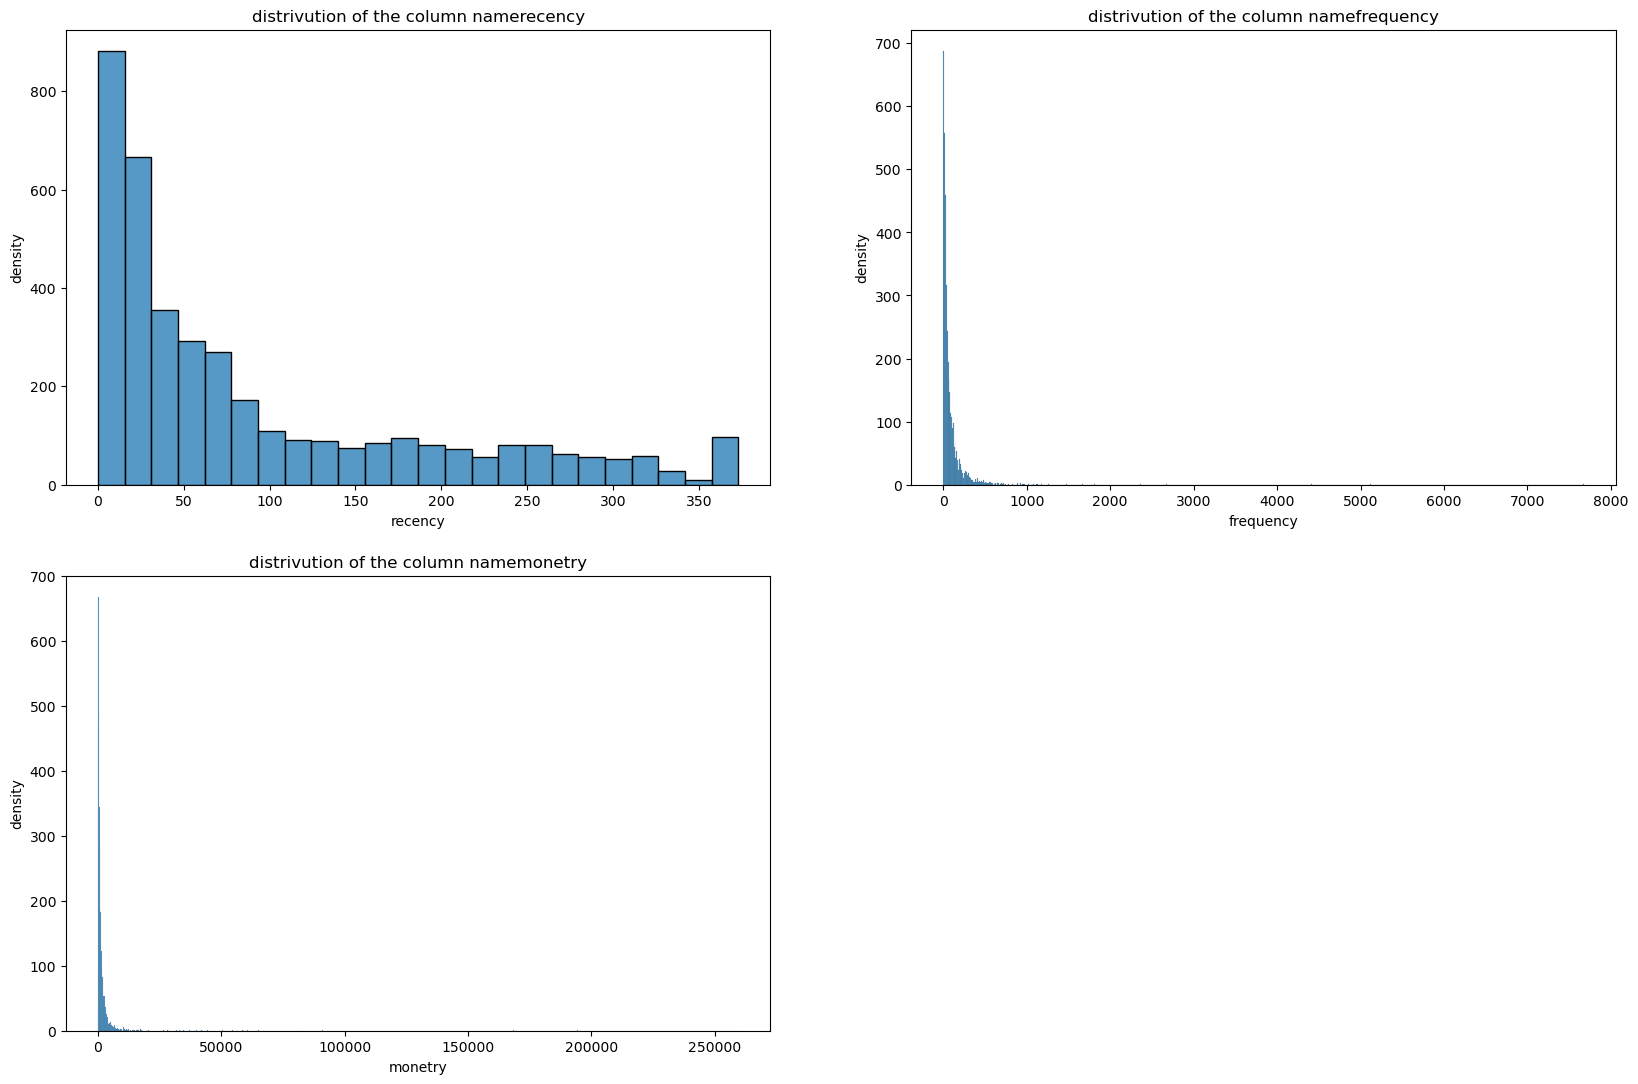

In [57]:
# plot the distribution of the columns
count=1
plt.subplots(figsize=(20,13))
for feature in rfm_df:
    plt.subplot(2,2,count)
    sns.histplot(rfm_df[feature])
    plt.title(f"distrivution of the column name{feature}")
    plt.xlabel(f"{feature}")
    plt.ylabel("density")
    count+=1

In [58]:
# now we use log for the balancing the scale of all the columns
def handling_negative(num):
    if num <= 0:
        return 1
    else:
        return num


# apply this function on columns recency and monetry
rfm_df['recency']=[handling_negative(x) for x in  rfm_df['recency']]
rfm_df['monetry']=[handling_negative(x) for x in  rfm_df['monetry']]

# now apply log on the columns
log_df=rfm_df[['recency','monetry','frequency']].apply(np.log,axis=1).round(3)

C:\Users\Arvind\AppData\Local\Temp\ipykernel_4068\2036687307.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(2,2,count)


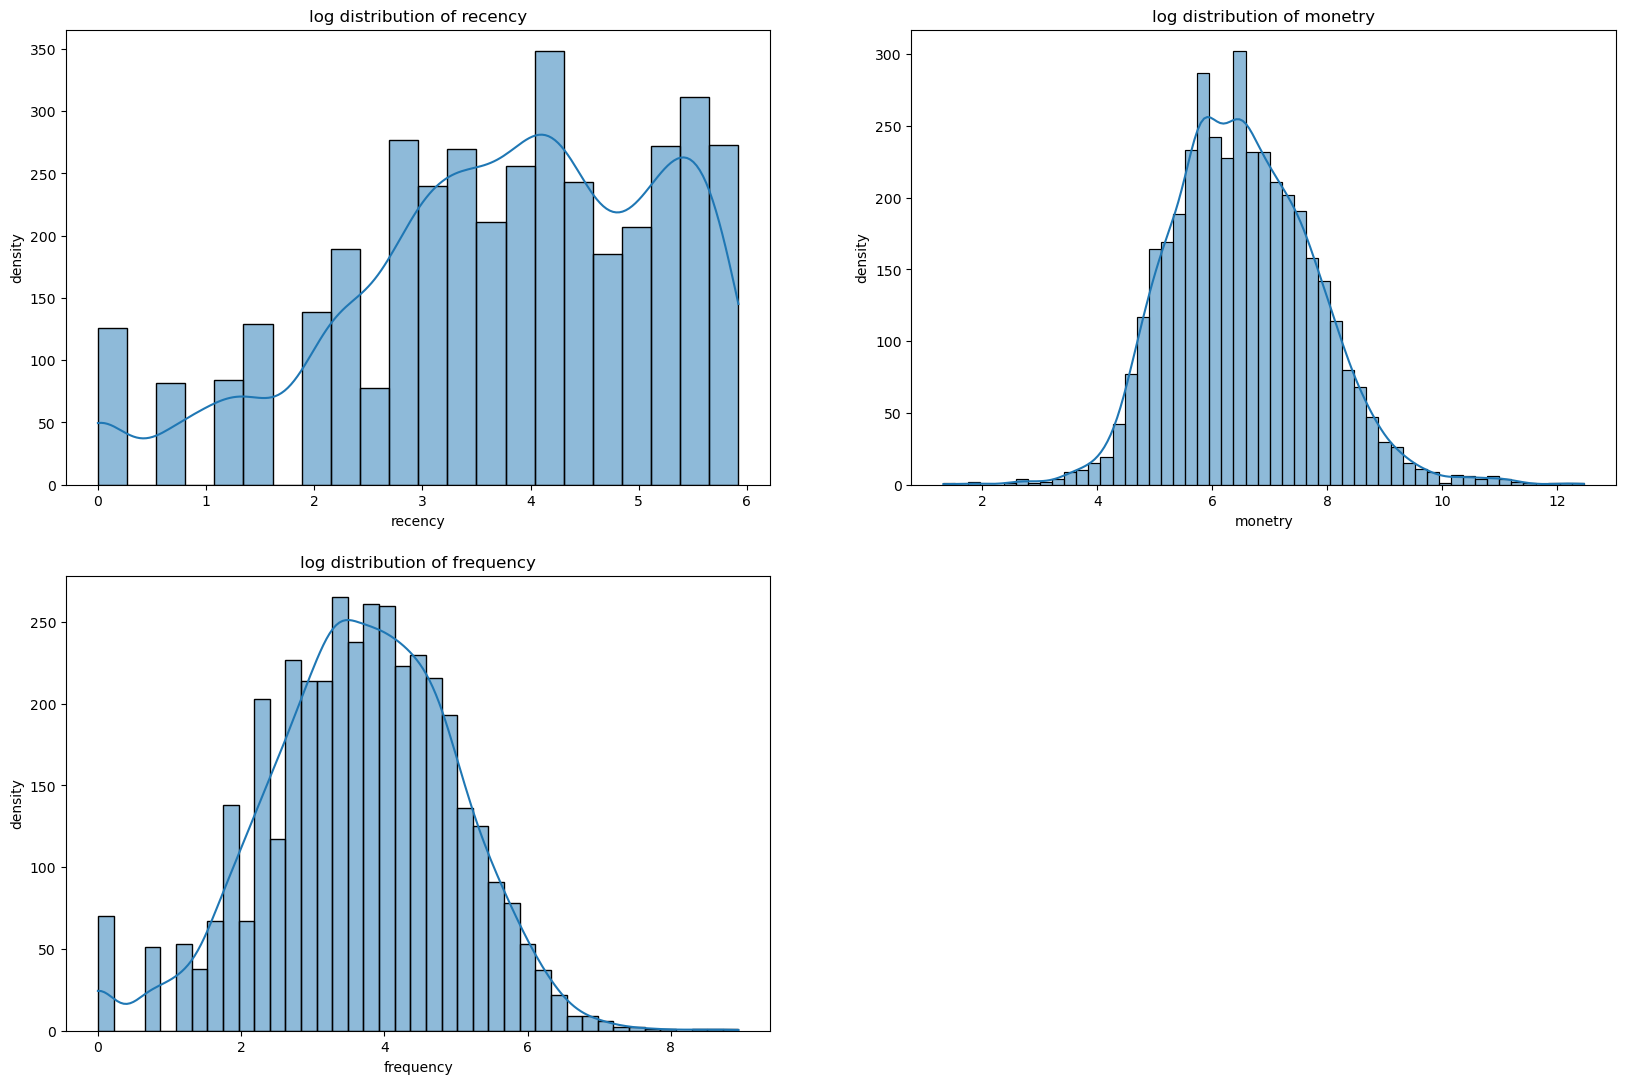

In [59]:
# now plot graph for the log distribution
count=1
plt.subplots(figsize=(20,13))
for feature in log_df:
    plt.subplot(2,2,count)
    sns.histplot(log_df[feature],kde=True)
    plt.title(f"log distribution of {feature}")
    plt.xlabel(f"{feature}")
    plt.ylabel("density")
    count+=1

In [60]:
# make or include log columns in main df
rfm_df['recency_log']=rfm_df['recency'].apply(math.log)
rfm_df['frequency_log']=rfm_df['frequency'].apply(math.log)
rfm_df['monetry_log']=rfm_df['monetry'].apply(math.log)

In [61]:
rfm_df.head()

,recency,frequency,monetry,recency_log,frequency_log,monetry_log
customerid,,,,,,
12346.0,325,1,77183.60,5.783825,0.000000,11.253942
12747.0,2,103,4196.01,0.693147,4.634729,8.341889
12748.0,1,4412,33053.19,0.000000,8.392083,10.405873
12749.0,3,199,4090.88,1.098612,5.293305,8.316515
12820.0,3,59,942.34,1.098612,4.077537,6.848366


In [62]:
# now scale our data
features=['recency_log',"frequency_log","monetry_log"]

# using standard scaler
x_features=rfm_df[features].values
scaler=StandardScaler()
x=scaler.fit_transform(x_features)


In [63]:
# ! pip install yellowbrick


In [64]:
# pip install --upgrade threadpoolctl

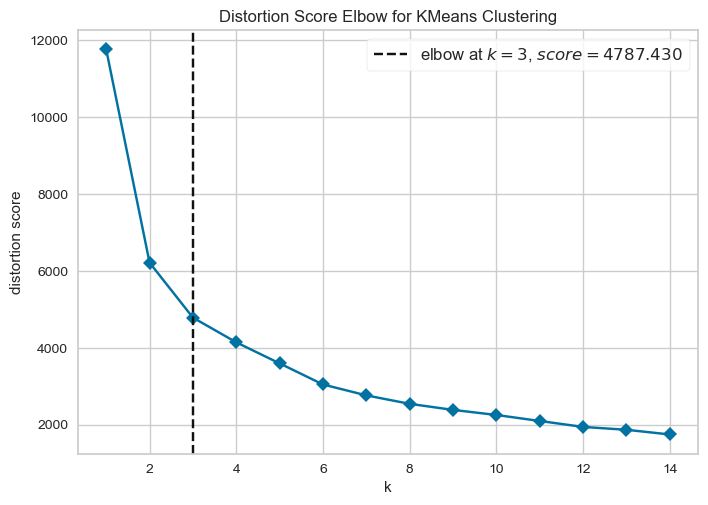

In [76]:
# elbow method to find out the best k
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans

# Fresh new KMeans — do NOT use the km from your loop
fresh_km = KMeans(init='k-means++', max_iter=1000, random_state=42)

SSE = {}
for k in range(1,15):
  km = KMeans(n_clusters = k, init = 'k-means++', max_iter = 1000)
  km = km.fit(x)
  SSE[k] = km.inertia_

# plot the graph for SSE and number of clusters
visualizer = KElbowVisualizer(km, k=(1,15), metric='distortion', timings=False,force_model=True)
visualizer.fit(x)
visualizer.poof()
plt.show()

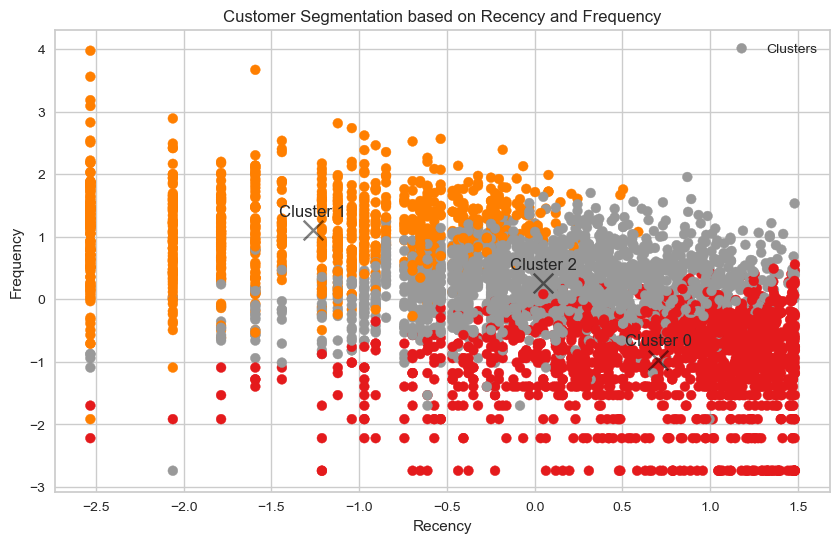

In [78]:
import matplotlib.pyplot as plt


# Assuming X is your data array
kmeans = KMeans(n_clusters=3)
kmeans.fit(x)
y_km = kmeans.predict(x)

# Plot the clusters
plt.figure(figsize=(10, 6))
plt.title('Customer Segmentation based on Recency and Frequency')
plt.scatter(x[:,0], x[:,1], c=y_km, s=50, cmap='Set1', label='Clusters')

# Plot and annotate the centers
centers = kmeans.cluster_centers_
plt.scatter(centers[:,0], centers[:,1], c='black', s=200, alpha=0.5, marker='x')
for i, center in enumerate(centers):
    plt.annotate(f'Cluster {i}', (center[0], center[1]), textcoords="offset points", xytext=(0,10), ha='center')

plt.xlabel('Recency')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [80]:
# Now split the rfm values to 4 quantiles
quantiles=rfm_df.quantile(q=[0.25,0.5,0.75,1.0])
quantiles=quantiles.to_dict()

In [82]:
def RScore(x,p,d):
    if x<=d[p][0.25]:
        return 1
    elif x<=d[p][0.5]:
        return 2
    elif x<=d[p][0.75]:
        return 3
    else:
        return 4

def FnMScore(x,p,d):
    if x<=d[p][0.25]:
        return 4
    elif x<=d[p][0.5]:
        return 3
    elif x<=d[p][0.75]:
        return 2
    else:
        return 1
    
    

In [84]:
# calculate rfm segment for all record
rfm_df['R']=rfm_df['recency'].apply(RScore,args=('recency',quantiles))
rfm_df['F']=rfm_df['frequency'].apply(RScore,args=('frequency',quantiles))
rfm_df['M']=rfm_df['monetry'].apply(RScore,args=('monetry',quantiles))
rfm_df.reset_index().head()

,customerid,recency,frequency,monetry,recency_log,frequency_log,monetry_log,R,F,M
0,12346.0,325,1,77183.60,5.783825,0.000000,11.253942,4,1,4
1,12747.0,2,103,4196.01,0.693147,4.634729,8.341889,1,4,4
2,12748.0,1,4412,33053.19,0.000000,8.392083,10.405873,1,4,4
3,12749.0,3,199,4090.88,1.098612,5.293305,8.316515,1,4,4
4,12820.0,3,59,942.34,1.098612,4.077537,6.848366,1,3,3


In [86]:
# Calculate RFM Group and RFM Score from the RFM segmentation:
rfm_df['RFMgroup']=rfm_df['R'].map(str)+rfm_df['F'].map(str)+rfm_df['M'].map(str)

# RFM score for rfm group column
rfm_df['RFMScore']=rfm_df[['R','F','M']].sum(axis=1)
rfm_df.reset_index().head()

,customerid,recency,frequency,monetry,recency_log,frequency_log,monetry_log,R,F,M,RFMgroup,RFMScore
0,12346.0,325,1,77183.60,5.783825,0.000000,11.253942,4,1,4,414,9
1,12747.0,2,103,4196.01,0.693147,4.634729,8.341889,1,4,4,144,9
2,12748.0,1,4412,33053.19,0.000000,8.392083,10.405873,1,4,4,144,9
3,12749.0,3,199,4090.88,1.098612,5.293305,8.316515,1,4,4,144,9
4,12820.0,3,59,942.34,1.098612,4.077537,6.848366,1,3,3,133,7


In [88]:
# find the clusters for the observations in the dataset
rfm_df['Cluster']=kmeans.labels_
rfm_df.head()

,recency,frequency,monetry,recency_log,frequency_log,monetry_log,R,F,M,RFMgroup,RFMScore,Cluster
customerid,,,,,,,,,,,,
12346.0,325,1,77183.60,5.783825,0.000000,11.253942,4,1,4,414,9,2
12747.0,2,103,4196.01,0.693147,4.634729,8.341889,1,4,4,144,9,1
12748.0,1,4412,33053.19,0.000000,8.392083,10.405873,1,4,4,144,9,1
12749.0,3,199,4090.88,1.098612,5.293305,8.316515,1,4,4,144,9,1
12820.0,3,59,942.34,1.098612,4.077537,6.848366,1,3,3,133,7,1


In [103]:
from IPython.display import FileLink
FileLink('Customer Segmentation.ipynb')

C:\Users\Arvind\Data Analysis Project\college project customer segmentation analysis\Customer Segmentation.ipynb

In [90]:
# Group by cluster label and calculate mean
cluster_average=rfm_df.groupby('Cluster').mean()
cluster_average.head()

,recency,frequency,monetry,recency_log,frequency_log,monetry_log,R,F,M,RFMgroup,RFMScore
Cluster,,,,,,,,,,,
0,166.417900,14.840733,285.116139,4.771471,2.370147,5.404062,3.309373,1.357294,1.430585,inf,6.097252
1,11.306698,254.151586,5806.548555,1.864721,5.133885,8.025179,1.219741,3.703878,3.753231,inf,8.676851
2,69.023030,67.794545,1175.195165,3.805606,3.993010,6.745419,2.442424,2.823030,2.773333,inf,8.038788


In [92]:
rfm_df.to_excel("customer_segment_rfm_df.xlsx", index=True)

In [93]:
rfm_df.reset_index().head()

,customerid,recency,frequency,monetry,recency_log,frequency_log,monetry_log,R,F,M,RFMgroup,RFMScore,Cluster
0,12346.0,325,1,77183.60,5.783825,0.000000,11.253942,4,1,4,414,9,2
1,12747.0,2,103,4196.01,0.693147,4.634729,8.341889,1,4,4,144,9,1
2,12748.0,1,4412,33053.19,0.000000,8.392083,10.405873,1,4,4,144,9,1
3,12749.0,3,199,4090.88,1.098612,5.293305,8.316515,1,4,4,144,9,1
4,12820.0,3,59,942.34,1.098612,4.077537,6.848366,1,3,3,133,7,1
